In [1]:
# auto reload modules
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
times = pd.read_csv('../../docs/times.tsv', sep='\t', header=None)
times.columns = ['command', 'threads', 'output', 'time']
times['command'] = times.apply(lambda row: 'bin-genes' if 'COSMIC' in row['output'] and row['command'] == 'bin' else ('bin-breaks' if row['command'] == 'bin' else row['command']), axis=1)
# drop where threads == 32
times = times[times['threads'] != 32]
times.head(7)

,command,threads,output,time
0,fill,1,./temp/PCAWG_cns_fill.tsv,89.622086
1,coverage,1,./temp/PCAWG_samples.tsv,0.559862
2,impute,1,./temp/PCAWG_cns_imp.tsv,43.693726
3,ploidy,1,./temp/PCAWG_samples.tsv,34.589319
4,bin-breaks,1,./temp/PCAWG_bin_1MB.tsv,80.197196
5,bin-genes,1,./temp/PCAWG_bin_COSMIC.tsv,25.001276
6,fill,2,./temp/PCAWG_cns_fill.tsv,49.392005


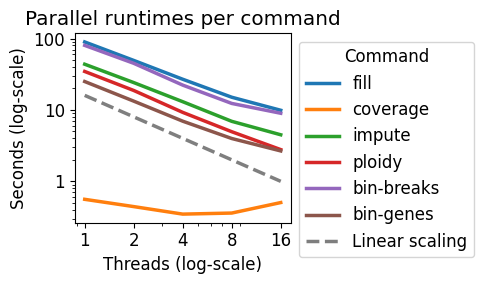

In [6]:
plt.rcParams.update({'font.size': 12}) 

# Get the unique commands
commands = times['command'].unique()
threads = times['threads'].unique()

plt.figure(figsize=(5, 3), dpi=100)

# Plot a line for each command
for cmd in commands:
    subset = times[times['command'] == cmd]
    plt.plot(subset['threads'], subset['time'], label=cmd, linewidth=2.5, alpha=1)

# add a y = -x line to show linear scaling
y_rev = np.array(threads)[::-1]
plt.plot(threads, y_rev, label='Linear scaling', linestyle='--', color='black', alpha=0.5, linewidth=2.5)

plt.xscale('log')
plt.yscale('log')
plt.xticks(threads, threads)
plt.yticks([1, 10, 100], [1, 10, 100])
plt.xlabel('Threads (log-scale)')
plt.ylabel('Seconds (log-scale)')
plt.title('Parallel runtimes per command')
# plot legend on the right of the box, title it 'Command'
plt.legend(title='Command', loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()

# save as a PDF
plt.savefig('../../docs/times.pdf', transparent=True)
plt.savefig('../../docs/times.pdf', transparent=True)
